=== Градиентный метод для максимизации ===
Итерация 0: x = [ 5. 10.], F = -80.0000, ||grad|| = 1.8974e+01
Итерация 1: x = [2. 1.], F = 10.0000, ||grad|| = 0.0000e+00

Результат максимизации:
Оптимальная точка: [2. 1.]
Максимальное значение функции: 10.0000


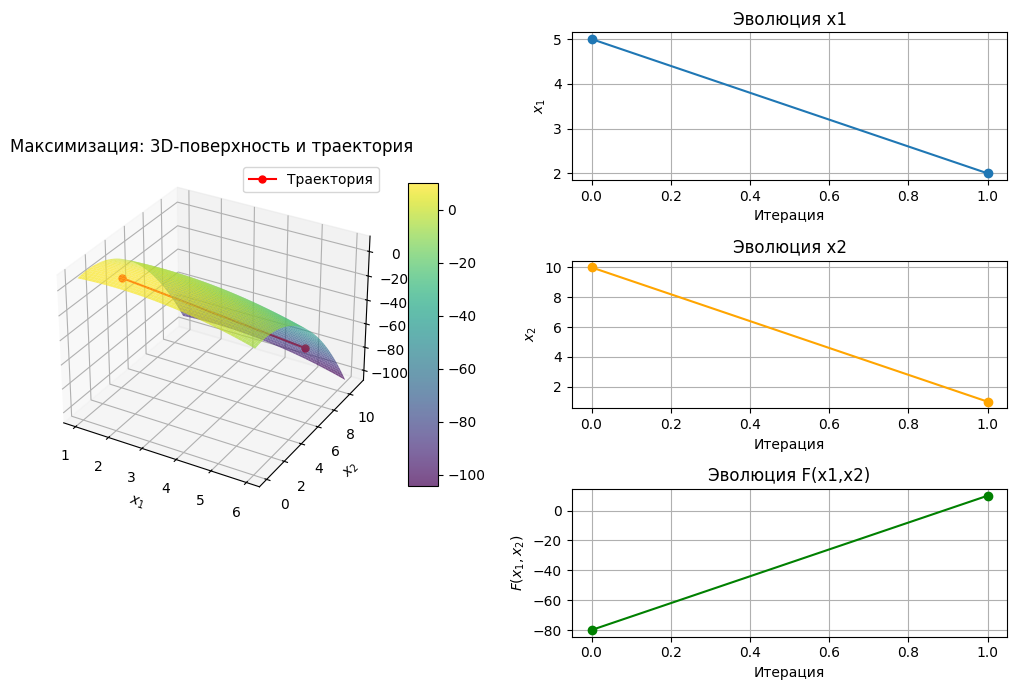


=== Овражный метод для минимизации ===
Итерация 0: x = [2. 4.], F = 413.200000, ||grad|| = 4.010162e+02
Итерация 1: x = [-0.00516127  3.98199855], F = 11.132762, ||grad|| = 3.592944e+00
Итерация 2: x = [-15.39919047  -4.79165496], F = 23693.116212, ||grad|| = 3.078838e+03
Итерация 3: x = [-0.0407818  -4.81246509], F = -4.867432, ||grad|| = 7.156753e+00
Итерация 4: x = [-0.00567937 -4.81283928], F = -4.995448, ||grad|| = 1.551337e-01
Итерация 5: x = [-0.04513517 -4.81289691], F = -4.834415, ||grad|| = 8.027383e+00
Итерация 6: x = [-0.00580202 -4.81327233], F = -4.995462, ||grad|| = 1.769416e-01
Итерация 7: x = [-0.03880699 -4.81340223], F = -4.881245, ||grad|| = 6.761809e+00
Итерация 8: x = [-0.00611135 -4.81377986], F = -4.995441, ||grad|| = 2.344197e-01
Итерация 9: x = [-0.02892103 -4.81391632], F = -4.938353, ||grad|| = 4.784785e+00
Итерация 10: x = [-0.00659428 -4.81429814], F = -4.995349, ||grad|| = 3.273937e-01
Итерация 11: x = [-0.0209093  -4.81441611], F = -4.970301, ||grad|| =

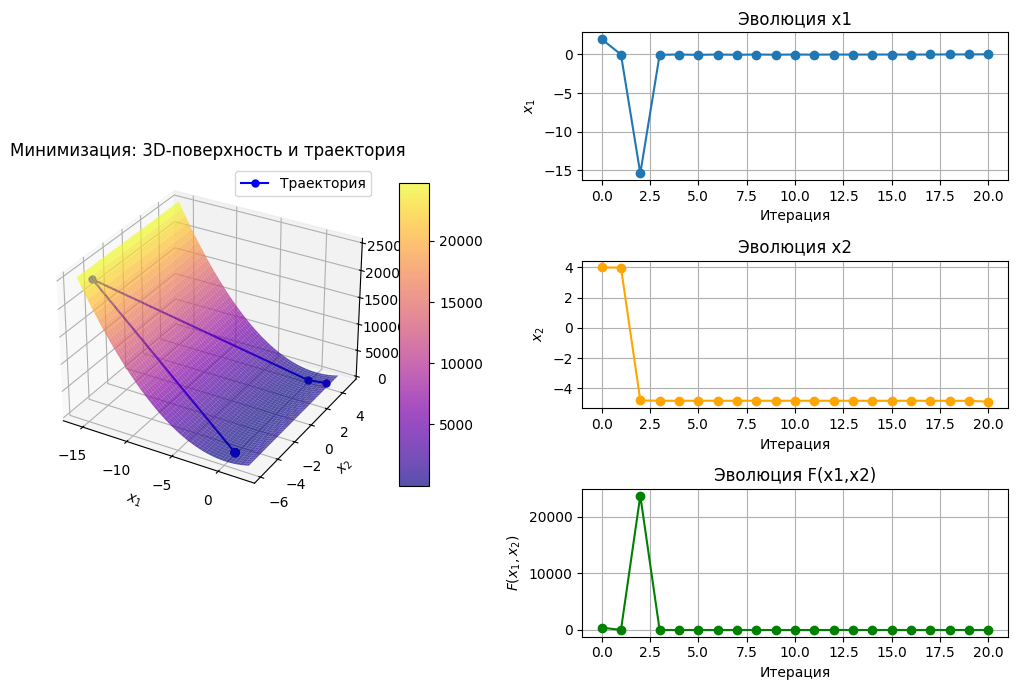

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Для 3D-графиков

# ======================= Задача 1: Максимизация с помощью градиентного метода =======================

def F_max(x):
    """
    Функция для максимизации:
        F(x1,x2) = 4*x1 + 2*x2 - x1**2 - x2**2 + 5
    """
    return 4*x[0] + 2*x[1] - x[0]**2 - x[1]**2 + 5

def gradF_max(x):
    """
    Градиент функции F_max:
        ∇F = (4 - 2*x1, 2 - 2*x2)
    """
    return np.array([4 - 2*x[0], 2 - 2*x[1]])

def gradient_ascent(x0, tol=1e-6, max_iter=10, alpha=0.5):
    """
    Градиентный метод для максимизации.
    Аргументы:
      x0      - начальная точка (numpy-массив)
      tol     - критерий остановки по норме градиента
      max_iter- максимальное число итераций
      alpha   - шаг метода (здесь известен аналитически)

    Возвращает:
      trajectory - массив точек решения (каждая строка - точка)
      f_values   - значения функции в точках траектории
    """
    x = x0.copy()
    trajectory = [x.copy()]
    f_values = [F_max(x)]

    print("=== Градиентный метод для максимизации ===")
    for k in range(max_iter):
        grad = gradF_max(x)
        norm_grad = np.linalg.norm(grad)
        print(f"Итерация {k}: x = {x}, F = {F_max(x):.4f}, ||grad|| = {norm_grad:.4e}")
        if norm_grad < tol:
            break
        x = x + alpha * grad
        trajectory.append(x.copy())
        f_values.append(F_max(x))
    return np.array(trajectory), np.array(f_values)

def plot_gradient_ascent(trajectory, f_values):
    """
    Строит два графика для задачи максимизации:
      1. 3D-поверхность функции с нанесённой траекторией поиска.
      2. 2D-графики эволюции x1, x2 и F по итерациям.
    """
    # Подготовка данных для 3D-графика
    x1_vals = np.linspace(min(trajectory[:,0]) - 1, max(trajectory[:,0]) + 1, 200)
    x2_vals = np.linspace(min(trajectory[:,1]) - 1, max(trajectory[:,1]) + 1, 200)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)
    Z = 4*X1 + 2*X2 - X1**2 - X2**2 + 5

    # 3D-график
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(121, projection='3d')
    surf = ax.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.7)
    # Траектория оптимизации
    Z_traj = np.array([F_max(pt) for pt in trajectory])
    ax.plot(trajectory[:,0], trajectory[:,1], Z_traj, 'r.-', markersize=10, label='Траектория')
    ax.set_title("Максимизация: 3D-поверхность и траектория")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_zlabel("$F(x_1,x_2)$")
    ax.legend()
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

    # 2D-графики изменения x1, x2 и F по итерациям
    iterations = np.arange(len(trajectory))
    ax1 = fig.add_subplot(322)
    ax1.plot(iterations, trajectory[:,0], 'o-', label='$x_1$')
    ax1.set_title("Эволюция x1")
    ax1.set_xlabel("Итерация")
    ax1.set_ylabel("$x_1$")
    ax1.grid(True)

    ax2 = fig.add_subplot(324)
    ax2.plot(iterations, trajectory[:,1], 'o-', label='$x_2$', color='orange')
    ax2.set_title("Эволюция x2")
    ax2.set_xlabel("Итерация")
    ax2.set_ylabel("$x_2$")
    ax2.grid(True)

    ax3 = fig.add_subplot(326)
    ax3.plot(iterations, f_values, 'o-', label='$F(x_1,x_2)$', color='green')
    ax3.set_title("Эволюция F(x1,x2)")
    ax3.set_xlabel("Итерация")
    ax3.set_ylabel("$F(x_1,x_2)$")
    ax3.grid(True)

    plt.tight_layout()
    plt.show()

# ======================= Задача 2: Минимизация с помощью овражного метода =======================

def F_min(x):
    """
    Функция для минимизации:
      F(x1,x2) = 100*x1**2 + 0.2*x2**2 + x1 + 2*x2
    """
    return 100*x[0]**2 + 0.2*x[1]**2 + x[0] + 2*x[1]

def gradF_min(x):
    """
    Градиент функции F_min:
      ∇F = (200*x1 + 1, 0.4*x2 + 2)
    """
    return np.array([200*x[0] + 1, 0.4*x[1] + 2])

# Гессиан (константный для квадратичной функции)
H = np.array([[200, 0],
              [0, 0.4]])

def ravine_method(x0, tol=1e-6, max_iter=20):
    """
    Овражный метод для минимизации.
    На каждом шаге:
      1. Вычисляется оптимальный шаг вдоль градиентного направления.
      2. Производится коррекция шага с учётом предыдущего направления (если оно существует).

    Возвращает:
      trajectory - массив точек траектории
      f_values   - значения функции в точках траектории
    """
    x_prev = x0.copy()
    x = x0.copy()
    trajectory = [x.copy()]
    f_values = [F_min(x)]

    print("\n=== Овражный метод для минимизации ===")
    for k in range(max_iter):
        grad = gradF_min(x)
        norm_grad = np.linalg.norm(grad)
        print(f"Итерация {k}: x = {x}, F = {F_min(x):.6f}, ||grad|| = {norm_grad:.6e}")
        if norm_grad < tol:
            break
        # Точный подбор шага для квадратичной функции:
        alpha = np.dot(grad, grad) / np.dot(grad, H @ grad)
        x_tilde = x - alpha * grad
        if k > 0:
            s = x - x_prev  # предыдущий шаг
            # Избегаем деления на ноль
            if np.linalg.norm(s) < 1e-12:
                beta = 0
            else:
                beta = np.dot(gradF_min(x_tilde), s) / np.dot(s, s)
            x_new = x_tilde - beta * s
        else:
            x_new = x_tilde
        x_prev = x.copy()
        x = x_new.copy()
        trajectory.append(x.copy())
        f_values.append(F_min(x))
    return np.array(trajectory), np.array(f_values)

def plot_ravine_method(trajectory, f_values):
    """
    Строит два графика для задачи минимизации:
      1. 3D-поверхность функции с нанесённой траекторией.
      2. 2D-графики изменения x1, x2 и F по итерациям.
    """
    # Подготовка данных для 3D-графика
    x1_vals = np.linspace(min(trajectory[:,0]) - 0.5, max(trajectory[:,0]) + 0.5, 200)
    x2_vals = np.linspace(min(trajectory[:,1]) - 1, max(trajectory[:,1]) + 1, 200)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)
    Z = 100*X1**2 + 0.2*X2**2 + X1 + 2*X2

    # 3D-график
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(121, projection='3d')
    surf = ax.plot_surface(X1, X2, Z, cmap='plasma', alpha=0.7)
    Z_traj = np.array([F_min(pt) for pt in trajectory])
    ax.plot(trajectory[:,0], trajectory[:,1], Z_traj, 'b.-', markersize=10, label='Траектория')
    ax.set_title("Минимизация: 3D-поверхность и траектория")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_zlabel("$F(x_1,x_2)$")
    ax.legend()
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

    # 2D-графики изменения переменных по итерациям
    iterations = np.arange(len(trajectory))
    ax1 = fig.add_subplot(322)
    ax1.plot(iterations, trajectory[:,0], 'o-', label='$x_1$')
    ax1.set_title("Эволюция x1")
    ax1.set_xlabel("Итерация")
    ax1.set_ylabel("$x_1$")
    ax1.grid(True)

    ax2 = fig.add_subplot(324)
    ax2.plot(iterations, trajectory[:,1], 'o-', label='$x_2$', color='orange')
    ax2.set_title("Эволюция x2")
    ax2.set_xlabel("Итерация")
    ax2.set_ylabel("$x_2$")
    ax2.grid(True)

    ax3 = fig.add_subplot(326)
    ax3.plot(iterations, f_values, 'o-', label='$F(x_1,x_2)$', color='green')
    ax3.set_title("Эволюция F(x1,x2)")
    ax3.set_xlabel("Итерация")
    ax3.set_ylabel("$F(x_1,x_2)$")
    ax3.grid(True)

    plt.tight_layout()
    plt.show()

# ======================= Основная часть программы =======================
def main():
    # Задача 1: Максимизация
    x0_max = np.array([5.0, 10.0])
    traj_max, f_values_max = gradient_ascent(x0_max, max_iter=10)
    print("\nРезультат максимизации:")
    print(f"Оптимальная точка: {traj_max[-1]}")
    print(f"Максимальное значение функции: {f_values_max[-1]:.4f}")
    plot_gradient_ascent(traj_max, f_values_max)

    # Задача 2: Минимизация
    x0_min = np.array([2.0, 4.0])
    traj_min, f_values_min = ravine_method(x0_min, max_iter=20)
    print("\nРезультат минимизации:")
    print(f"Оптимальная точка: {traj_min[-1]}")
    print(f"Минимальное значение функции: {f_values_min[-1]:.6f}")
    plot_ravine_method(traj_min, f_values_min)

if __name__ == "__main__":
    main()
